In [9]:
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
jr.init_cluster()

#parameters
nx = 128
ny = 128
nz = 128
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 0.1
t_end = 6.0
cfl_safety = 0.5 #this is pretty aggressive
spatial_dimensions=3
snap_path="data/physics_engine_tests/"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

x = jnp.linspace(0, Lx, nx, endpoint=False)
y = jnp.linspace(0, Ly, ny, endpoint=False)
z = jnp.linspace(0, Lz, nz, endpoint=False)

x_grid = x.reshape(1,-1,1)
y_grid = y.reshape(1,1,-1)
z_grid = z.reshape(-1,1,1)


#initialize arrays
#modified Orzag-Tang vortex as described in Loureiro et al. 2016 (Viriato paper)
phi = (jnp.cos(x_grid+1.4) + jnp.cos(y_grid+0.5)) * jnp.sin(z_grid)
psi = (jnp.cos(2.0*x_grid+2.3) + jnp.cos(y_grid + 4.1)) * jnp.cos(z_grid)

#fft
phik=ft.rfft2(phi)
psik=ft.rfft2(psi)

#set up orbax snapshot manager
mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,diss=(visc,res),hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
shardings=jr.setup_sharding(params)
kgrid = jr.setup_kgrids(params)
state = jr.SimulationState(t=0.0,fields=jnp.stack((phik,psik)))

nblock = jr.estimate_good_nblock(state,kgrid,params,t_snap,t_end,nblock_min=1)
print("nblock estimate: "+str(nblock))

Running in local mode. Total devices: 1
nblock estimate: 8


In [2]:
jr.simulate_scan(state,kgrid,params,nblock,t_snap=t_snap,t_end=t_end,mngr=mngr,shardings=shardings)

Saving initial state as snapshot 0
0.08990366621972566
0.17928863789012145
Saving snapshot 1
0.2679762304123107
0.3557473683424738
Saving snapshot 2
0.44230908114733297
0.5263556885818649
Saving snapshot 3
0.6070564820717335
0.6841579736211408
Saving snapshot 4
0.7576823426758438
0.8278645535643927
Saving snapshot 5
0.8949931030206225
0.9592846258126578
Saving snapshot 6
1.0208132278245399
1.0798318446040724
Saving snapshot 7
1.1363710988854532
1.1882775866180244
Saving snapshot 8
1.238585168028464
1.2887520405579211
Saving snapshot 9
1.3402439707048224
1.3912243239797315
Saving snapshot 10
1.44199953709353
1.4902875821549861
1.5381422310109825
Saving snapshot 11
1.5864467907067907
1.6351396587378475
1.6846274133630177
Saving snapshot 12
1.735088997160719
1.7851730307941762
Saving snapshot 13
1.8349714458251143
1.886265814574968
Saving snapshot 14
1.937045889418297
1.987165245351036
Saving snapshot 15
2.0362634617011035
2.0838150630126333
2.1301156390606315
Saving snapshot 16
2.1754546

'Ending simulation at t = 6.022068632252983. It took 159.49917199998163s'

In [10]:
s=jr.simulate(state,kgrid,params,t_snap,t_end,mngr,shardings)

Saving initial state as snapshot 0
Saving snapshot 1 at t = 0.10107494789961104
Saving snapshot 2 at t = 0.2014557915501214
Saving snapshot 3 at t = 0.31183095201850397
Saving snapshot 4 at t = 0.4205974049781994
Saving snapshot 5 at t = 0.5258760744993208
Saving snapshot 6 at t = 0.6259493140801381
Saving snapshot 7 at t = 0.7295533789965244
Saving snapshot 8 at t = 0.8352128975438408
Saving snapshot 9 at t = 0.9420622777767718
Saving snapshot 10 at t = 1.0490367319372593
Saving snapshot 11 at t = 1.1491945145110205
Saving snapshot 12 at t = 1.2512254960538034
Saving snapshot 13 at t = 1.3566077002057328
Saving snapshot 14 at t = 1.4600442046356734
Saving snapshot 15 at t = 1.5630157664318678
Saving snapshot 16 at t = 1.6668758271161954
Saving snapshot 17 at t = 1.7718329503919776
Saving snapshot 18 at t = 1.875396643098281
Saving snapshot 19 at t = 1.9766495775545905
Saving snapshot 20 at t = 2.079600050248861
Saving snapshot 21 at t = 2.1824884161202633
Saving snapshot 22 at t = 2.2

In [12]:
vort=ft.irfft2(-kgrid.ksq()*s.fields[0,:,:,:])

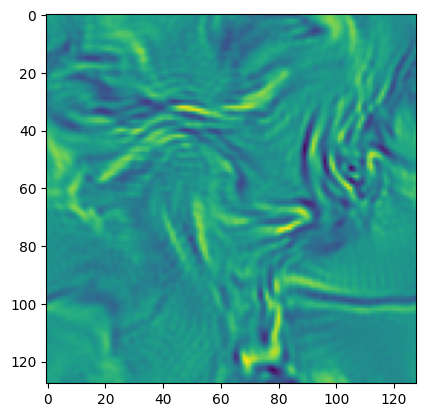

In [13]:
plt.imshow(vort[64,:,:])